<a href="https://colab.research.google.com/github/fernandinhaalmeida84/Tech_Challenge_Fase_2/blob/main/Notebook/01_An%C3%A1lise_Explorat%C3%B3ria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 1: Análise Exploratória das bases de Dados**

Nesta etapa, o objetivo é conhecer as bases de dados utilizadas no projeto, compreender as estruturas, identificar padrões, distribuições, valores ausentes, possíveis duplicidades e outliers.

In [53]:
# 1. Baixa o arquivo zip direto do GitHub (usando ?raw=true) para o ambiente do Colab
!wget -O /content/BaseDadosFase2.zip https://github.com/fernandinhaalmeida84/Tech_Challenge_Fase_2/blob/1462573e4453793ed0c8e218b35ece6ce166caee/Data/Raw/BaseDadosFase2.zip?raw=true

# 2. Descompacta o arquivo em uma pasta chamada 'dados_extraidos'
!unzip -o /content/BaseDadosFase2.zip -d dados_extraidos

--2026-10-09 19:07:28--  https://github.com/fernandinhaalmeida84/Tech_Challenge_Fase_2/blob/1462573e4453793ed0c8e218b35ece6ce166caee/Data/Raw/BaseDadosFase2.zip?raw=true
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/fernandinhaalmeida84/Tech_Challenge_Fase_2/raw/1462573e4453793ed0c8e218b35ece6ce166caee/Data/Raw/BaseDadosFase2.zip [following]
--2026-10-09 19:07:28--  https://github.com/fernandinhaalmeida84/Tech_Challenge_Fase_2/raw/1462573e4453793ed0c8e218b35ece6ce166caee/Data/Raw/BaseDadosFase2.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fernandinhaalmeida84/Tech_Challenge_Fase_2/1462573e4453793ed0c8e218b35ece6ce166caee/Data/Raw/BaseDadosFase2.zip [following]
--2026-10-09 19:07:29--  https://raw.githubusercontent.com/fernandinhaalmeida8

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

In [55]:
df_cadastro = pd.read_csv("dados_extraidos/application_record.csv", sep=",")

In [56]:
df_cadastro.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0




#**Arquivo Application_record.csv**

## **1. Examinando a estrutura do arquivo cadastro (Application_record.csv)**

O arquivo possui 18 colunas e 438557 linhas. Porém, a quantidade de ID único é de 438510, ou seja, podem ter ID duplicados.

Visando melhor entendimento, listamos a coluna e o seu o significado em português:

---


 - ID – Código do cliente
 - CODE_GENDER - Gênero
 - FLAG_OWN_CAR - Possui carro
 - FLAG_OWN_REALTY – Possui imóvel próprio
 - CNT_CHILDREN - Qtd de filhos
 - AMT_INCOME_TOTAL - Renda total declarada
 - NAME_INCOME_TYPE - Tipo/fonte de renda
 - NAME_EDUCATION_TYPE – Nível de escolaridade
 - NAME_FAMILY_STATUS - Estado civil
 - NAME_HOUSING_TYPE - Tipo de moradia
 - DAYS_BIRTH – Idade em dias
 - DAYS_EMPLOYED – Tempo de serviço em dias
 - FLAG_MOBIL - Possui celular
 - FLAG_WORK_PHONE - Telefone do trabalho
 - FLAG_PHONE  - Telefone cadastrado
 - FLAG_EMAIL- E-mail cadastrado
 - OCCUPATION_TYPE – Profissão/ocupação
 - CNT_FAM_MEMBERS – Qtd de pessoas no núcleo familiar


In [57]:
df_cadastro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [58]:
df_cadastro.shape

(438557, 18)

In [59]:
df_cadastro['ID'].nunique()

438510

**Observação sobre os IDs repetidos**

A base cadastral contém 438.557 registros e 438.510 IDs distintos. Essa diferença indica que alguns IDs aparecem em mais de um registro. Nesta etapa, apenas registramos essa característica da base, sem excluir ou alterar registros.

In [60]:
df_cadastro.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,438557.0,NaN,NaN,NaN,6022176.269842,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CODE_GENDER,438557,2,F,294440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,438557,2,N,275459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,438557,2,Y,304074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,438557.0,NaN,NaN,NaN,0.42739,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,NaN,NaN,NaN,187524.28601,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
NAME_INCOME_TYPE,438557,5,Working,226104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_EDUCATION_TYPE,438557,5,Secondary / secondary special,301821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_FAMILY_STATUS,438557,5,Married,299828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_HOUSING_TYPE,438557,6,House / apartment,393831,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##**2. Valores ausentes**

Tratamos valores ausentes para não dar resultados equivocados nas avaliações.

Em OCCUPATION_TYPE encontramos 134.203 valores ausentes, realizamos o tratamento e substituímos esses valores pela categoria "Unknown".

In [61]:
df_cadastro.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [62]:
df_cadastro['OCCUPATION_TYPE'] = df_cadastro['OCCUPATION_TYPE'].fillna('Unknown')

In [63]:
df_cadastro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

##**3. Limpeza e tratamento dos dados**

As colunas DAYS_BIRTH e DAYS_EMPLOYED estão com os dados em dias e com valores negativos.

Realizamos os seguintes tratamentos de dados:

* Para otimizar o tratamento de dados, criamos a coluna "Idade", objetivando converter os dias de nascimento em anos e utilizando o valor aproximado de 365,25 dias por ano, devido aos anos bissextos.

In [64]:
df_cadastro['Idade'] = (df_cadastro['DAYS_BIRTH'] * -1) / 365.25



* Na coluna DAYS_EMPLOYED, identificamos o valor positivo "365243", que é um código especial da base e não representa um período laboral. Esse valor costuma estar associado a pessoas sem um período de emprego convencional registrado, incluindo situações de "Desemprego ou aposentadoria". Para identificar esses registros, criamos a variável "Desempregado ou aposentado", que recebe "True" quando DAYS_EMPLOYED é igual a 365243 e False nos demais casos.

In [65]:
df_cadastro['Desempregado ou aposentado'] = df_cadastro['DAYS_EMPLOYED'] == 365243

In [66]:
df_cadastro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          438557 non-null  int64  
 1   CODE_GENDER                 438557 non-null  object 
 2   FLAG_OWN_CAR                438557 non-null  object 
 3   FLAG_OWN_REALTY             438557 non-null  object 
 4   CNT_CHILDREN                438557 non-null  int64  
 5   AMT_INCOME_TOTAL            438557 non-null  float64
 6   NAME_INCOME_TYPE            438557 non-null  object 
 7   NAME_EDUCATION_TYPE         438557 non-null  object 
 8   NAME_FAMILY_STATUS          438557 non-null  object 
 9   NAME_HOUSING_TYPE           438557 non-null  object 
 10  DAYS_BIRTH                  438557 non-null  int64  
 11  DAYS_EMPLOYED               438557 non-null  int64  
 12  FLAG_MOBIL                  438557 non-null  int64  
 13  FLAG_WORK_PHON

* Criamos a variável "Anos_Trabalhados", convertendo os dias em anos e invertendo o sinal dos valores negativos para obter resultados positivos. Como regra de tratamento, atribuímos zero anos trabalhados aos registros com o código especial 365243. Optamos por essa convenção que não tem relação intrínseca com a ausência efetiva de período trabalhado.

In [67]:
df_cadastro['Anos_Trabalhados'] = df_cadastro['DAYS_EMPLOYED'].apply(lambda x: 0.0 if x == 365243 else (x * -1) / 365.25)

In [68]:
# Criando Anos_Trabalhados com uma regra consistente
# 365243 é um código especial da base, não um tempo real de emprego.
df_cadastro['Anos_Trabalhados'] = np.where(
    df_cadastro['DAYS_EMPLOYED'] == 365243,
    0,
    -df_cadastro['DAYS_EMPLOYED'] / 365.25
)

display(df_cadastro[[
    'DAYS_EMPLOYED',
    'Desempregado ou aposentado',
    'Anos_Trabalhados'
]].head(10))


,DAYS_EMPLOYED,Desempregado ou aposentado,Anos_Trabalhados
0,-4542,False,12.435318
1,-4542,False,12.435318
2,-1134,False,3.104723
3,-3051,False,8.353183
4,-3051,False,8.353183
5,-3051,False,8.353183
6,-3051,False,8.353183
7,365243,True,0.000000
8,365243,True,0.000000
9,365243,True,0.000000


Conferimos abaixo a inclusão do "Unknow" nos dados ausentes, e a inclusão das colunas Idade, Desempregado ou aposentado e Anos_Trabalhados

In [69]:
display(df_cadastro[['ID', 'OCCUPATION_TYPE', 'Idade', 'Desempregado ou aposentado', 'Anos_Trabalhados']].head())

,ID,OCCUPATION_TYPE,Idade,Desempregado ou aposentado,Anos_Trabalhados
0,5008804,Unknown,32.867899,False,12.435318
1,5008805,Unknown,32.867899,False,12.435318
2,5008806,Security staff,58.792608,False,3.104723
3,5008808,Sales staff,52.320329,False,8.353183
4,5008809,Sales staff,52.320329,False,8.353183


##**4. Identificação de outliers**

Analisamos cada variável numérica relevante para entender o comportamento de seus outliers por meio de métricas estatísticas e visualizações gráficas (Boxplot e Histograma).

Os tratamentos os outliers será definido após a verificação de inconsistências e a avaliação do impacto dessa variável nos modelos preditivos.

*   **4.1 - Análise da Renda Total**

A renda apresenta assimetria à direita, com concentração de valores em faixas inferiores e presença de rendas mais elevadas.
Identificamos  19.108 registroa acima do Limite superior para outlier, de  R$ 380,250.00, correspondente a 4,36% da base.






--- AMT_INCOME_TOTAL ---
Limite superior para outlier: R$ 380,250.00
Quantidade de registros acima do limite: 19108 (4.36%)
Maior renda registrada: R$ 6,750,000.00


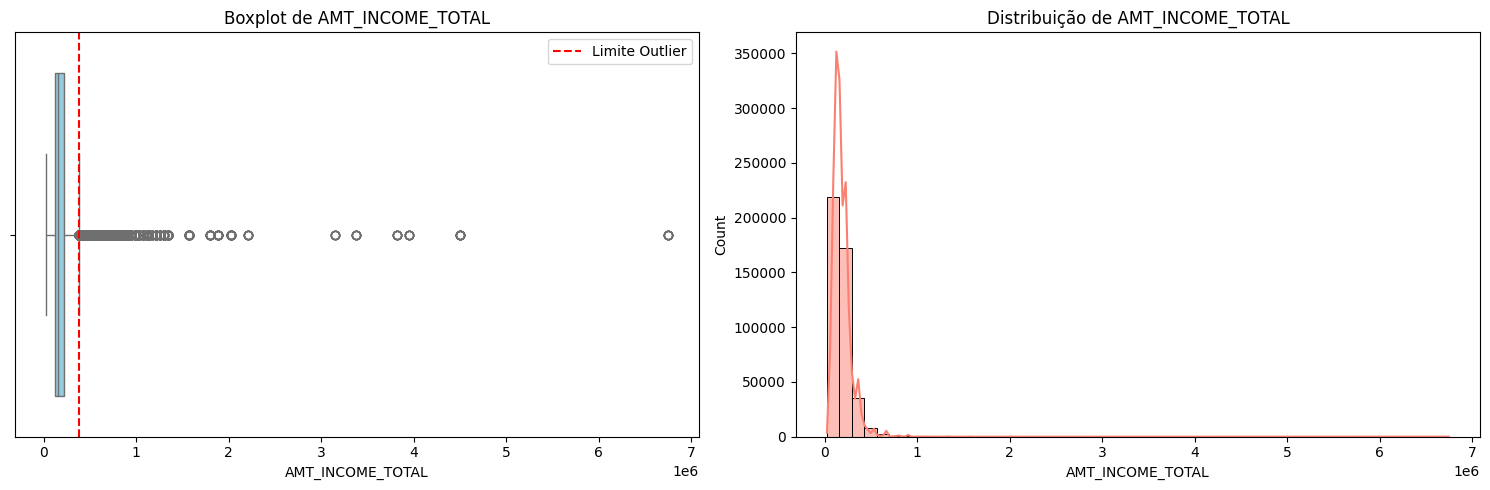

In [70]:
col = 'AMT_INCOME_TOTAL'
Q1 = df_cadastro[col].quantile(0.25)
Q3 = df_cadastro[col].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df_cadastro[df_cadastro[col] > limite_superior]
print(f"--- {col} ---")
print(f"Limite superior para outlier: R$ {limite_superior:,.2f}")
print(f"Quantidade de registros acima do limite: {outliers.shape[0]} ({outliers.shape[0]/df_cadastro.shape[0]*100:.2f}%)")
print(f"Maior renda registrada: R$ {df_cadastro[col].max():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_cadastro[col], color='skyblue')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Outlier')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_cadastro[col], bins=50, kde=True, color='salmon')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

*   **4.2 Análise do tempo de serviço**

A distribuição do tempo de serviço apresenta assimetria à direita pronunciada. A grande maioria dos indivíduos possui menos de 19,72 anos de trabalho. Há uma proporção relevante de outliers (5,01%), que se estendem aé o valor máximo de 48 anos.

--- Anos_Trabalhados ---
Limite superior para outlier: 19.72 anos
Quantidade de registros acima do limite: 21971 (5.01%)
Máximo de anos trabalhados registrado: 48.00 anos


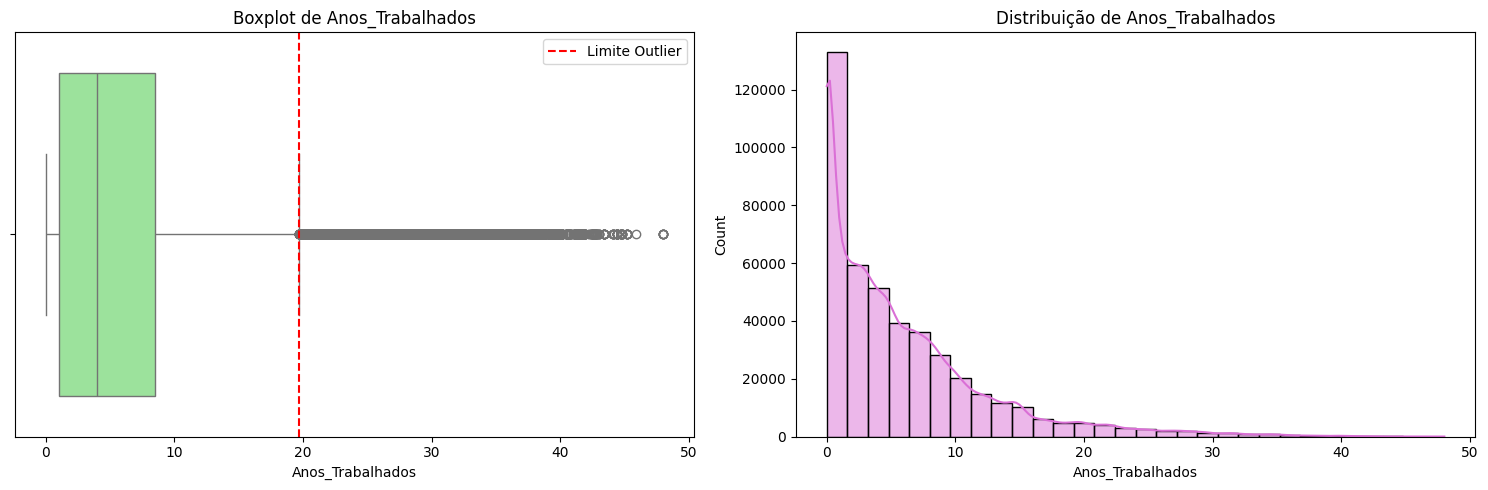

In [72]:
# Criando a coluna Anos_Trabalhados com base em DAYS_EMPLOYED
# Valores positivos em DAYS_EMPLOYED (como 365243) indicam desemprego, então definimos como 0.
df_cadastro['Anos_Trabalhados'] = df_cadastro['DAYS_EMPLOYED'].apply(lambda x: -x / 365.25 if x < 0 else 0)

col = 'Anos_Trabalhados'
Q1 = df_cadastro[col].quantile(0.25)
Q3 = df_cadastro[col].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df_cadastro[df_cadastro[col] > limite_superior]
print(f"--- {col} ---")
print(f"Limite superior para outlier: {limite_superior:.2f} anos")
print(f"Quantidade de registros acima do limite: {outliers.shape[0]} ({outliers.shape[0]/df_cadastro.shape[0]*100:.2f}%)")
print(f"Máximo de anos trabalhados registrado: {df_cadastro[col].max():.2f} anos")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_cadastro[col], color='lightgreen')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Outlier')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_ca[col], bins=30, kde=True, color='orchid')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

*   **4.3 Análise da Idade**

A variável "Idade" apresenta uma distribuição bem-comportada, sem presença de outliers estatísticos. Todos os registros pertecem à faixa 20,5 a 69 anos, o que é coerente com uma população adulta e ativa.

--- Idade ---
Limite inferior para outlier: 5.64 anos
Limite superior para outlier: 81.96 anos
Quantidade de registros fora dos limites: 0 (0.00%)
Idade mínima registrada: 20.50 anos
Idade máxima registrada: 69.00 anos


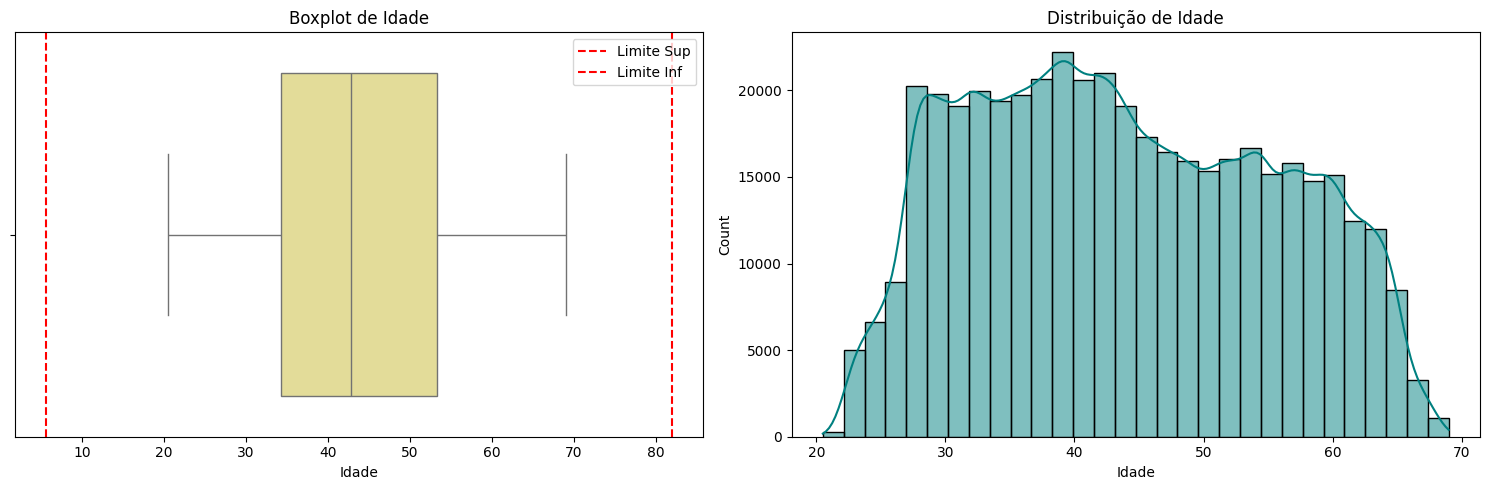

In [73]:
col = 'Idade'
Q1 = df_cadastro[col].quantile(0.25)
Q3 = df_cadastro[col].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_cadastro[(df_cadastro[col] < limite_inferior) | (df_cadastro[col] > limite_superior)]

print(f"--- {col} ---")
print(f"Limite inferior para outlier: {limite_inferior:.2f} anos")
print(f"Limite superior para outlier: {limite_superior:.2f} anos")
print(f"Quantidade de registros fora dos limites: {outliers.shape[0]} ({outliers.shape[0]/df_cadastro.shape[0]*100:.2f}%)")
print(f"Idade mínima registrada: {df_cadastro[col].min():.2f} anos")
print(f"Idade máxima registrada: {df_cadastro[col].max():.2f} anos")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_cadastro[col], color='khaki')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Sup')
axes[0].axvline(limite_inferior, color='red', linestyle='--', label='Limite Inf')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_cadastro[col], bins=30, kde=True, color='teal')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

*   **4.4 Análise da Quantidade de Membros da Família**

A maioria das famílias da base possui entre 1 e 4 membros. Existe um pequeno volume de outliers (1,30%), mas alguns com valoes discrepantes, como 20 membros na familía (o que pode ser até erro de digitação/coleta ou dadp atípicos de famílias numerosas).

--- CNT_FAM_MEMBERS ---
Limite inferior para outlier: 0.50
Limite superior para outlier: 4.50
Quantidade de registros fora dos limites: 5690 (1.30%)
Mínimo de membros familiar registrado: 1
Máximo de membros familiar registrado: 20


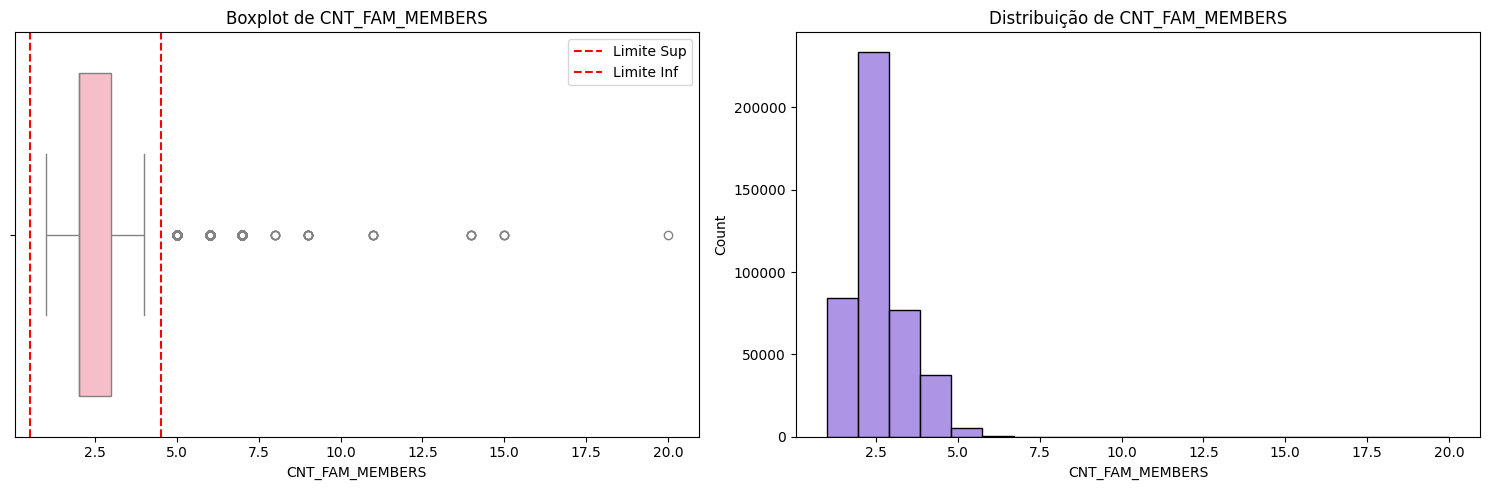

In [74]:
col = 'CNT_FAM_MEMBERS'
Q1 = df_cadastro[col].quantile(0.25)
Q3 = df_cadastro[col].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_cadastro[(df_cadastro[col] < limite_inferior) | (df_cadastro[col] > limite_superior)]

print(f"--- {col} ---")
print(f"Limite inferior para outlier: {limite_inferior:.2f}")
print(f"Limite superior para outlier: {limite_superior:.2f}")
print(f"Quantidade de registros fora dos limites: {outliers.shape[0]} ({outliers.shape[0]/df_cadastro.shape[0]*100:.2f}%)")
print(f"Mínimo de membros familiar registrado: {df_cadastro[col].min():.0f}")
print(f"Máximo de membros familiar registrado: {df_cadastro[col].max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_cadastro[col], color='lightpink')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Sup')
axes[0].axvline(limite_inferior, color='red', linestyle='--', label='Limite Inf')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_cadastro[col], bins=20, kde=False, color='mediumpurple')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

### **Conclusão da Análise de Outliers e Próximos Passos**

A análise exploratória identificou a presença de valores atípicos (*outliers*) em variáveis numéricas chave da base:

1. **Tempo de Serviço (\`Anos_Trabalhados\`):** Apresenta 5,01% de registros acima do limite superior (19,72 anos).
2. **Tamanho Familiar (\`CNT_FAM_MEMBERS\`):** Possui 1,30% de registros discrepantes com valores até 20 membros.
3. **Renda (\`Renda\`):** Apresenta assimetria acentuada à direita, típica de variáveis financeiras.

**Decisão Metodológica:**
* visando a preservação dos dados, nenhum registro será deletado nesta etapa para evitar perda de informação relevante.
* o tratamento será implementado na etapa de Pré-processamento, após a divisão da base em Treino e Teste (Train/Test Split) para prevenir "Data Leakage".

* Estratégia por Variável:
  - \`Anos_Trabalhados\`: Aplicação de *Winsorization* (Capping) no limite superior do IQR do conjunto de treino.
  - \`CNT_FAM_MEMBERS\`: Truncamento fixo no valor 5 (agrupamento de valores superiores).
  - \`Renda\`: Transformação logarítmica \`np.log1p()\` para suavizar a assimetria e estabilizar a variância.

#**Arquivo credit_record.csv**

## **5. Examinando a estrutura do arquivo credito (credit_record.csv)**

O arquivo possui 3 colunas e 1048575 linhas. Porém, apresentam 45985 ID de clientes diferentes.

Para melhor entendimento, escrevemos o significado das colunas em português:

* ID - Código do cliente
* MONTHS_BALANCE - Qtd de meses do balanço em relação ao atual
* STATUS - Situação do pagamento do cliente naquele mês.

In [75]:
df_credito = pd.read_csv('dados_extraidos/credit_record.csv', sep=",")

In [76]:
df_credito.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [77]:
df_credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [78]:
df_credito.shape

(1048575, 3)

In [79]:
df_credito['ID'].nunique()

45985

In [80]:
df_credito.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,1048575.0,NaN,NaN,NaN,5068286.424673,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,NaN,NaN,NaN,-19.136998,14.023498,-60.0,-29.0,-17.0,-7.0,0.0
STATUS,1048575,8,C,442031,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##**6.  Análise da coluna Status**

A coluna Status indica a situação do pagamento do cliente em cada mês.

No conjunto de dados, os valores têm esta definição:
- C: Pago (dentro do prazo).
- X: Sem empréstimo ou transações ativos no mês.
- 0: 1-29 dias de atraso.
- 1: 30-59 dias de atraso.
- 2: 60-89 dias de atraso.
- 3: 90-119 dias de atraso.
- 4: 120-149 dias de atraso.
- 5: Mais de 150 dias de atraso (prejuízo)

In [82]:
status_counts = df_credito["STATUS"].value_counts()

status_share = df_credito["STATUS"].value_counts(normalize=True).round(4)

pd.DataFrame({"contagem": status_counts, "proporção": status_share})

,contagem,proporção
STATUS,,
C,442031,0.4216
0,383120,0.3654
X,209230,0.1995
1,11090,0.0106
5,1693,0.0016
2,868,0.0008
3,320,0.0003
4,223,0.0002


A coluna `STATUS` representa a situação **mensal** do histórico de crédito de cada cliente. Seus códigos numéricos formam uma escala crescente de gravidade: o status `0` indica atraso de 1 a 29 dias, enquanto o status `5` representa atraso de 150 dias ou mais, associado a uma situação de maior inadimplência.

Os códigos `C` e `X` possuem significados distintos dos códigos numéricos. O status `C` indica que a fatura daquele mês foi paga em dia, enquanto `X` indica ausência de crédito ativo no mês.

In [83]:
print("Distribuição dos valores da coluna STATUS:")

ordem_status = ['C', 'X', '0', '1', '2', '3', '4', '5']

legenda_status = {
    'C': 'Pago (dentro do prazo)',
    'X': 'Sem transações ativas no mês',
    '0': 'Atraso de 1 a 29 dias',
    '1': 'Atraso de 30 a 59 dias',
    '2': 'Atraso de 60 a 89 dias',
    '3': 'Atraso de 90 a 119 dias',
    '4': 'Atraso de 120 a 149 dias',
    '5': 'Atraso de 150 dias ou mais (prejuízo)'
}

contagem = df_credito['STATUS'].value_counts()
proporcao = df_credito['STATUS'].value_counts(normalize=True) * 100

resumo_status = pd.DataFrame({
    'STATUS': ordem_status,
    'Count': contagem.reindex(ordem_status, fill_value=0).values,
    'Proportion': proporcao.reindex(ordem_status, fill_value=0).round(6).values,
    'Legenda': [legenda_status[s] for s in ordem_status],
    'Percentual (%)': proporcao.reindex(ordem_status, fill_value=0).round(2).values
})

# Centralizar os dados e os títulos, ocultando o índice numérico
display(
    resumo_status.style
    .hide(axis='index')
    .set_properties(**{
        'text-align': 'center',
        'vertical-align': 'middle'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('text-align', 'center'),
                ('vertical-align', 'middle')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('padding', '8px')
            ]
        }
    ])
    .format({
        'Proportion': '{:.6f}',
        'Percentual (%)': '{:.2f}%'
    })
)

Distribuição dos valores da coluna STATUS:


STATUS,Count,Proportion,Legenda,Percentual (%)
C,442031,42.155401,Pago (dentro do prazo),42.16%
X,209230,19.953747,Sem transações ativas no mês,19.95%
0,383120,36.537205,Atraso de 1 a 29 dias,36.54%
1,11090,1.057626,Atraso de 30 a 59 dias,1.06%
2,868,0.082779,Atraso de 60 a 89 dias,0.08%
3,320,0.030518,Atraso de 90 a 119 dias,0.03%
4,223,0.021267,Atraso de 120 a 149 dias,0.02%
5,1693,0.161457,Atraso de 150 dias ou mais (prejuízo),0.16%


Para concatenar os dados, construímos uma tabela organizando os status em ordem de agravamento e exibe a quantidade de registros (`Count`), a proporção (`Proportion`), a descrição de cada código (`Legenda`) e o percentual correspondente (`Percentual (%)`).

É importante distinguir registros mensais de clientes inadimplentes: cada linha da base credit_record.csv representa um cliente em determinado mês, e um mesmo cliente pode aparecer várias vezes. Portanto, os percentuais apresentados indicam a distribuição dos status mensais, não a proporção de bons e maus pagadores.

##**7. Análise da coluna MONTHS_BALANCE**

A coluna MONTHS_BALANCE indica a distância em meses até o mês de referência dos dados: 0 é o mês mais recente disponível, e valores negativos (-1, -2, ...) são meses anteriores.

A coluna MONTHS_BALANC possui resultados que variam de 0 a -60, o que significa:
- 0: O mês atual (mês mais recente registrado).
- -1: Um mês atrás.
- -2: Dois meses atrás.
...
- -60: 60 meses atrás (5 anos de histórico).

In [84]:
print("Análise da coluna MONTHS_BALANCE:")

valores_unicos = sorted(
    df_excel2['MONTHS_BALANCE'].dropna().unique(),
    reverse=True
)

print("Menor valor:", df_excel2['MONTHS_BALANCE'].min())
print("Maior valor:", df_excel2['MONTHS_BALANCE'].max())
print("Quantidade de valores únicos:", df_excel2['MONTHS_BALANCE'].nunique())
print("Valores únicos:", valores_unicos)

Análise da coluna MONTHS_BALANCE:
Menor valor: -60
Maior valor: 0
Quantidade de valores únicos: 61
Valores únicos: [np.int64(0), np.int64(-1), np.int64(-2), np.int64(-3), np.int64(-4), np.int64(-5), np.int64(-6), np.int64(-7), np.int64(-8), np.int64(-9), np.int64(-10), np.int64(-11), np.int64(-12), np.int64(-13), np.int64(-14), np.int64(-15), np.int64(-16), np.int64(-17), np.int64(-18), np.int64(-19), np.int64(-20), np.int64(-21), np.int64(-22), np.int64(-23), np.int64(-24), np.int64(-25), np.int64(-26), np.int64(-27), np.int64(-28), np.int64(-29), np.int64(-30), np.int64(-31), np.int64(-32), np.int64(-33), np.int64(-34), np.int64(-35), np.int64(-36), np.int64(-37), np.int64(-38), np.int64(-39), np.int64(-40), np.int64(-41), np.int64(-42), np.int64(-43), np.int64(-44), np.int64(-45), np.int64(-46), np.int64(-47), np.int64(-48), np.int64(-49), np.int64(-50), np.int64(-51), np.int64(-52), np.int64(-53), np.int64(-54), np.int64(-55), np.int64(-56), np.int64(-57), np.int64(-58), np.int64(-

* **Qualidade da base "credit_record.csv"**

Um cliente aparecer em vários meses é esperado. Vamos verificar valores ausentes, linhas integralmente duplicadas e registros repetidos para a mesma combinação de ID e mês. O objetivo não é apagar dados, mas traçar estratégias para melhor definição do target.

In [85]:
print('Dimensões da base:', df_excel2.shape)

print('\nValores ausentes por coluna:')
display(df_excel2.isna().sum())

print('\nIDs únicos:', df_excel2['ID'].nunique())
print('Linhas integralmente duplicadas:', df_excel2.duplicated().sum())
print(
    'Duplicatas na combinação ID + mês:',
    df_excel2.duplicated(
        subset=['ID', 'MONTHS_BALANCE']
    ).sum()
)


Dimensões da base: (1048575, 3)

Valores ausentes por coluna:


,0
ID,0
MONTHS_BALANCE,0
STATUS,0



IDs únicos: 45985
Linhas integralmente duplicadas: 0
Duplicatas na combinação ID + mês: 0


A base de histórico de crédito contém **1.048.575 registros, 3 colunas e 45.985 clientes distintos. **

Não foram identificados valores ausentes, linhas integralmente duplicadas ou duplicatas na combinação ID e MONTHS_BALANCE, indicando que cada cliente possui, no máximo, um registro por mês.

* **Duração do histórico por cliente**


Clientes com históricos mais longos têm mais oportunidades de apresentar atraso. Essa diferença tende a influenciar um Target baseado em ter apresentado atraso em algum momento e deverá ser considerada como limitação do projeto.

In [86]:
historico_cliente = (
    df_excel2.groupby('ID')
    .agg(
        MESES_OBSERVADOS=('MONTHS_BALANCE', 'nunique'),
        MES_MAIS_RECENTE=('MONTHS_BALANCE', 'max'),
        MES_MAIS_ANTIGO=('MONTHS_BALANCE', 'min')
    )
    .reset_index()
)

print('Resumo dos meses observados por cliente:')
display(historico_cliente['MESES_OBSERVADOS'].describe())

Resumo dos meses observados por cliente:


,MESES_OBSERVADOS
count,45985.000000
mean,22.802544
std,15.492771
min,1.000000
25%,10.000000
50%,19.000000
75%,34.000000
max,61.000000


A análise identificou 45.985 clientes, com média de 22,80 meses observados e mediana de 19 meses. A quantidade de meses varia de 1 a 61, indicando que os clientes possuem ranges distintos e amplos que podem tornar o modelo impreciso, caso conclua que clientes com históricos mais longos são mais arriscados.


In [87]:
historico_cliente = (
    df_excel2.groupby('ID')
    .agg(
        MESES_OBSERVADOS=('MONTHS_BALANCE', 'nunique'),
        MES_MAIS_RECENTE=('MONTHS_BALANCE', 'max'),
        MES_MAIS_ANTIGO=('MONTHS_BALANCE', 'min')
    )
    .reset_index()
)

print('\nDistribuição da quantidade de meses (primeiras 20 categorias):')
display(
    historico_cliente['MESES_OBSERVADOS']
    .value_counts()
    .sort_index()
    .head(20)
)



Distribuição da quantidade de meses (primeiras 20 categorias):


,count
MESES_OBSERVADOS,
1,399
2,1088
3,1163
4,1339
5,1227
6,1439
7,1457
8,1531
9,1421


# **9. Síntese da análise exploratória**

**Base cadastral - application_record.csv**
- A base cadastral reúne características pessoais e financeiras.
- 438.557 registros, 438.510 IDs distintos e 18 colunas originais.
- Na coluna OCCUPATION_TYPE, há valores ausentes que foram tratados como categoria "Unknown".
- O código 365243 de `DAYS_EMPLOYED` é tratado como valor especial para "Desempregado ou aposentado".
- A transformação logarítmica reduz a assimetria, mas não equivale a excluir ou limitar outliers.

**Base de crédito - credit record.csv**
- A base de crédito contém registros mensais; os percentuais de `STATUS` não representam diretamente percentuais de clientes.
- A duração do histórico varia entre clientes e pode influenciar a construção do Target.


In [89]:
# célula de encerramento do Notebook 01
from pathlib import Path

# 1. Pasta local do Colab (não depende do Google Drive)
PROCESSED_DIR = Path('/content/Data/Processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# 2. Salvar ambos os DataFrames tratados
OUTPUT_PATH_APP = PROCESSED_DIR / 'application_record_tratado.parquet'
OUTPUT_PATH_CREDIT = PROCESSED_DIR / 'credit_record_tratado.parquet'

df_cadastro.to_parquet(OUTPUT_PATH_APP, index=False)
df_credito.to_parquet(OUTPUT_PATH_CREDIT, index=False)

print(f"✅ Base de cadastros salva em: {OUTPUT_PATH_APP}")
print(f"✅ Base de créditos salva em: {OUTPUT_PATH_CREDIT}")

# 3. (Só para você) baixar os arquivos e subir no GitHub
from google.colab import files
files.download(str(OUTPUT_PATH_APP))
files.download(str(OUTPUT_PATH_CREDIT))

✅ Base de cadastros salva em: /content/Data/Processed/application_record_tratado.parquet
✅ Base de créditos salva em: /content/Data/Processed/credit_record_tratado.parquet


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>